In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Load dataset
df = pd.read_csv("HHS_Validated_Data.csv")

## Ensure Date is datetime and sort chronologically

In [18]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

## 1. Total System Load
 CBP Custody + HHS Care


In [19]:
df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

## 2. Net Daily Intake
 Transfers into HHS − Discharges from HHS

In [20]:
df["Net Daily Intake"] = (
    df["Children transferred out of CBP custody"] -
    df["Children discharged from HHS Care"]
)

## 3. Care Load Growth Rate (%)
 Day-over-day percentage change

In [22]:
df["Care Load Growth Rate (%)"] = (
    df["Total System Load"]
      .pct_change() * 100
)

# Replace first NaN with 0
df["Care Load Growth Rate (%)"] = (
    df["Care Load Growth Rate (%)"]
      .fillna(0)
)

## 4. Backlog Indicator
 Positive Net Intake = Backlog Increasing

In [23]:
df["Backlog Indicator"] = np.where(
    df["Net Daily Intake"] > 0,
    "Increasing",
    np.where(
        df["Net Daily Intake"] < 0,
        "Decreasing",
        "Stable"
    )
)

## 5. Consecutive Backlog Days (Optional)
 Number of consecutive days backlog increased

In [24]:
positive = df["Net Daily Intake"] > 0

df["Backlog Days"] = (
    positive.groupby((~positive).cumsum())
            .cumcount() + 1
)

df.loc[~positive, "Backlog Days"] = 0

## Display Results

In [25]:
print(df[[
    "Date",
    "Total System Load",
    "Net Daily Intake",
    "Care Load Growth Rate (%)",
    "Backlog Indicator",
    "Backlog Days"
]].head())

        Date  Total System Load  Net Daily Intake  Care Load Growth Rate (%)  \
0 2023-01-02             7935.0            -204.0                   0.000000   
1 2023-01-03             7903.0               0.0                  -0.403277   
2 2023-01-04             7903.0               0.0                   0.000000   
3 2023-01-05             8807.0             -85.0                  11.438694   
4 2023-01-06             7084.0            -219.0                 -19.563983   

  Backlog Indicator  Backlog Days  
0        Decreasing             0  
1            Stable             0  
2            Stable             0  
3        Decreasing             0  
4        Decreasing             0  


## Save Dataset


In [26]:

# df.to_csv("HHS_Derived_Metrics.csv", index=False)

# print("Derived healthcare capacity metrics created successfully.")

Derived healthcare capacity metrics created successfully.


# Trend & Temporal Analysis


In [28]:
# Set Date as index
df = df.set_index("Date")

## 1. Daily Care Load Trend

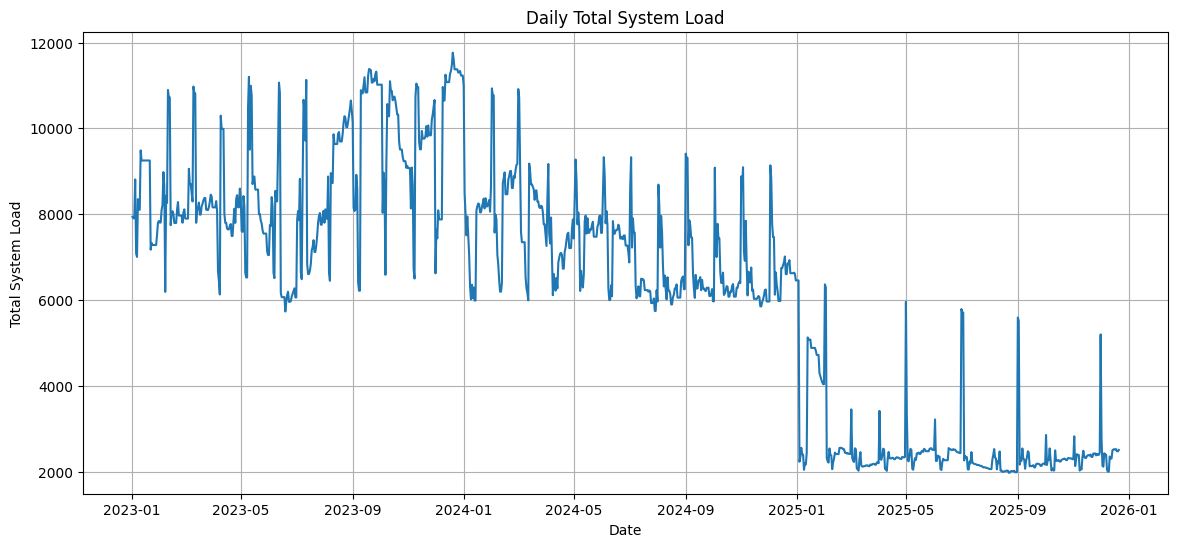

In [30]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df["Total System Load"], linewidth=1.5)
plt.title("Daily Total System Load")
plt.xlabel("Date")
plt.ylabel("Total System Load")
plt.grid(True)
plt.show()

## 2. Weekly Care Load Trend

In [ ]:
weekly_load = df["Total System Load"].resample("W").mean()

plt.figure(figsize=(14,6))
plt.plot(weekly_load.index, weekly_load.values, linewidth=2)
plt.title("Weekly Average Care Load")
plt.xlabel("Week")
plt.ylabel("Average Load")
plt.grid(True)
plt.show()

## 3. Monthly Care Load Trend

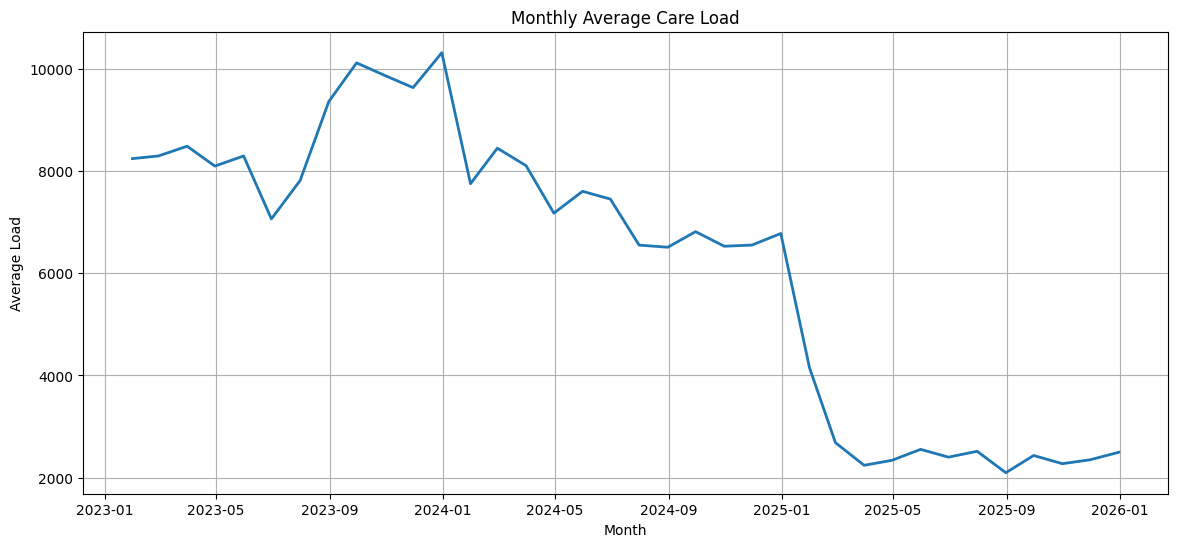

In [32]:
monthly_load = df["Total System Load"].resample("ME").mean()

plt.figure(figsize=(14,6))
plt.plot(monthly_load.index, monthly_load.values, linewidth=2)
plt.title("Monthly Average Care Load")
plt.xlabel("Month")
plt.ylabel("Average Load")
plt.grid(True)
plt.show()

## 4. Identify Sustained High-Load Periods
 (7-day rolling average)

High Load Days:
            Total System Load  7-Day Rolling Load
Date                                             
2023-03-12            10814.0         9544.428571
2023-05-14             8700.0         9735.714286
2023-05-15             8865.0        10070.285714
2023-05-16             8876.0         9842.285714
2023-05-17             8572.0         9466.857143
...                       ...                 ...
2024-01-02             8485.0        10830.714286
2024-01-03             8026.0        10361.714286
2024-01-04             7506.0         9814.428571
2024-03-02            10718.0         9527.571429
2024-03-03             9062.0         9552.714286

[108 rows x 2 columns]


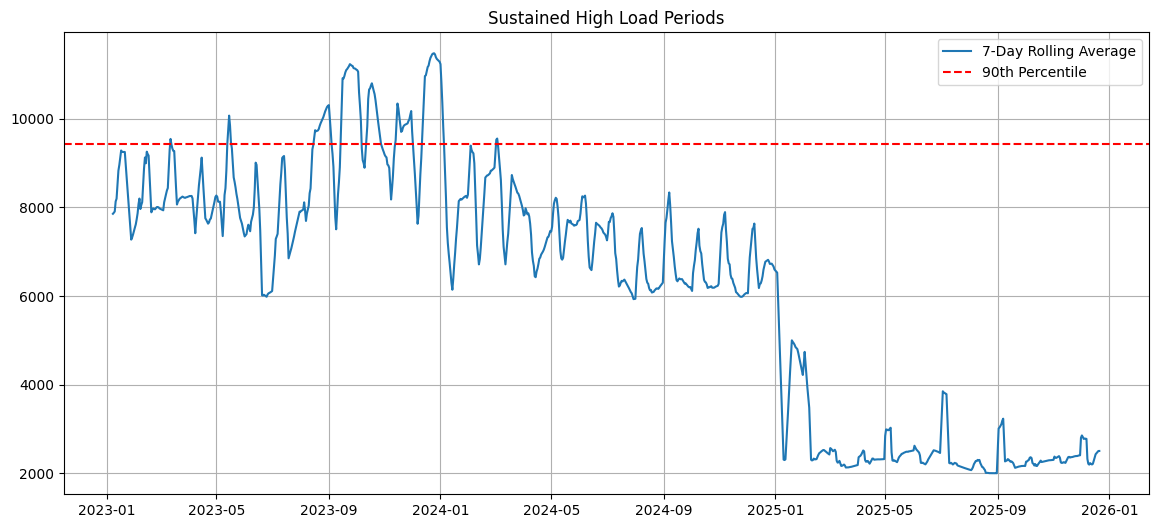

In [33]:
df["7-Day Rolling Load"] = (
    df["Total System Load"]
    .rolling(window=7)
    .mean()
)

threshold = df["7-Day Rolling Load"].quantile(0.90)

df["High Load Period"] = df["7-Day Rolling Load"] > threshold

print("High Load Days:")
print(df[df["High Load Period"]][["Total System Load","7-Day Rolling Load"]])

# Plot
plt.figure(figsize=(14,6))
plt.plot(df.index, df["7-Day Rolling Load"], label="7-Day Rolling Average")
plt.axhline(threshold, color="red", linestyle="--", label="90th Percentile")
plt.legend()
plt.title("Sustained High Load Periods")
plt.grid(True)
plt.show()


## 5. Early vs Late Timeline Comparison

In [34]:
mid_date = df.index.min() + (df.index.max() - df.index.min()) / 2

early = df[df.index <= mid_date]
late = df[df.index > mid_date]

comparison = pd.DataFrame({
    "Period": ["Early Timeline", "Late Timeline"],
    "Average Load": [
        early["Total System Load"].mean(),
        late["Total System Load"].mean()
    ],
    "Maximum Load": [
        early["Total System Load"].max(),
        late["Total System Load"].max()
    ],
    "Minimum Load": [
        early["Total System Load"].min(),
        late["Total System Load"].min()
    ]
})

print(comparison)

           Period  Average Load  Maximum Load  Minimum Load
0  Early Timeline   8458.791897       11762.0        5730.0
1   Late Timeline   3954.732472        9408.0        1972.0


## 6. Monthly Summary Table

In [36]:
monthly_summary = (
    df["Total System Load"]
    .resample("ME")
    .agg(["mean","max","min","std"])
)

print(monthly_summary)

                    mean      max     min          std
Date                                                  
2023-01-31   8240.933333   9485.0  7002.0   886.093516
2023-02-28   8292.428571  10894.0  6188.0   985.601957
2023-03-31   8483.516129  10974.0  7797.0   838.785069
2023-04-30   8094.400000  10294.0  6127.0   959.109271
2023-05-31   8292.709677  11200.0  6523.0  1230.809251
2023-06-30   7060.766667  11065.0  5730.0  1476.322988
2023-07-31   7811.612903  11129.0  6058.0  1242.238079
2023-08-31   9357.741935  10647.0  6446.0  1083.036040
2023-09-30  10113.600000  11382.0  6214.0  1662.532688
2023-10-31   9863.354839  11097.0  6585.0  1029.353537
2023-11-30   9629.733333  11043.0  6498.0  1064.290372
2023-12-31  10312.354839  11762.0  6619.0  1620.573860
2024-01-31   7750.096774  10994.0  5986.0  1067.295347
2024-02-29   8444.827586  10932.0  6192.0  1258.642610
2024-03-31   8102.064516  10914.0  5990.0  1103.957847
2024-04-30   7173.600000   9169.0  6110.0   642.998128
2024-05-31

In [37]:
# # Save summaries
# comparison.to_csv("Timeline_Comparison.csv", index=False)
# monthly_summary.to_csv("Monthly_Care_Load_Summary.csv")

# Pressure & Stress Identification
- Rolling averages (7-day, 14-day)
- Variability analysis
- Detection of prolonged strain windows

In [39]:
# sort date
df = df.sort_values("Date")

## 1. Rolling Averages

In [40]:
# 7-Day Rolling Average
df["7-Day Rolling Avg"] = (
    df["Total System Load"]
    .rolling(window=7, min_periods=1)
    .mean()
)

# 14-Day Rolling Average
df["14-Day Rolling Avg"] = (
    df["Total System Load"]
    .rolling(window=14, min_periods=1)
    .mean()
)

## 2. Variability Analysis

In [41]:
# Rolling Standard Deviation
df["7-Day Std Dev"] = (
    df["Total System Load"]
    .rolling(window=7, min_periods=1)
    .std()
)

df["14-Day Std Dev"] = (
    df["Total System Load"]
    .rolling(window=14, min_periods=1)
    .std()
)

# Coefficient of Variation (%)
df["CV (%)"] = (
    df["7-Day Std Dev"] /
    df["7-Day Rolling Avg"]
) * 100

## 3. Detect Prolonged Strain Windows

In [43]:
# Threshold = 90th percentile
threshold = df["Total System Load"].quantile(0.90)

df["High Load"] = df["Total System Load"] >= threshold

# Consecutive high-load days
groups = (~df["High Load"]).cumsum()

df["Consecutive High Load Days"] = (
    df["High Load"]
      .groupby(groups)
      .cumcount() + 1
)

df.loc[~df["High Load"], "Consecutive High Load Days"] = 0

# Define strain window (≥7 consecutive high-load days)
df["Prolonged Strain"] = (
    df["Consecutive High Load Days"] >= 7
)

## 4. Summary

In [44]:
print("Pressure & Stress Summary")
print("-------------------------")
print(f"High Load Threshold : {threshold:.0f}")
print(f"Total High Load Days : {df['High Load'].sum()}")
print(f"Prolonged Strain Days : {df['Prolonged Strain'].sum()}")


Pressure & Stress Summary
-------------------------
High Load Threshold : 9876
Total High Load Days : 109
Prolonged Strain Days : 52


## 5. Visualization

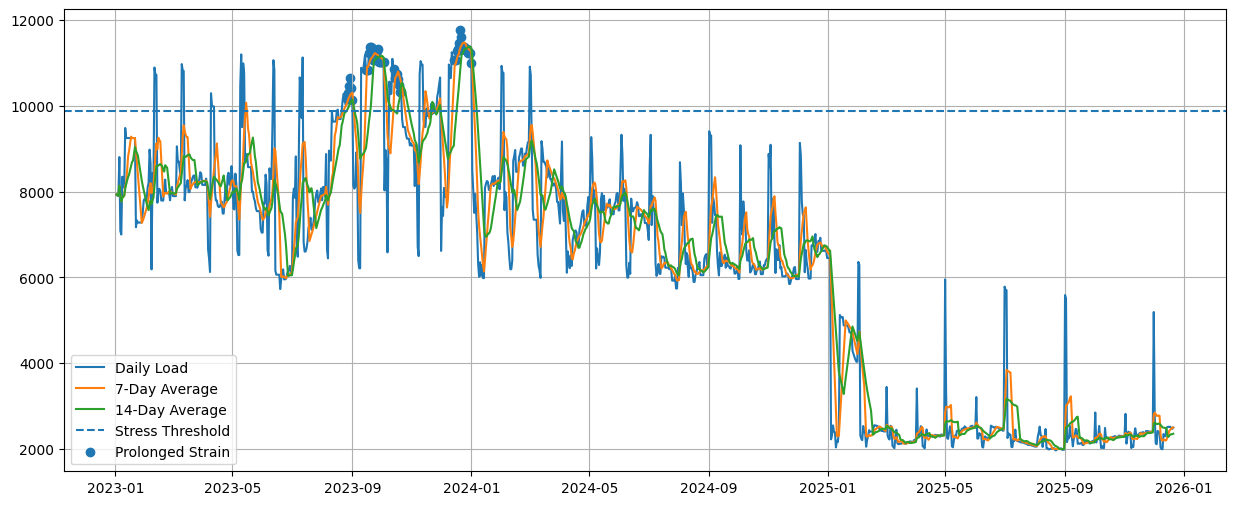

In [47]:
plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Total System Load"],
         label="Daily Load")

plt.plot(df.index,
         df["7-Day Rolling Avg"],
         label="7-Day Average")

plt.plot(df.index,
         df["14-Day Rolling Avg"],
         label="14-Day Average")

plt.axhline(y=threshold,
            linestyle="--",
            label="Stress Threshold")

plt.scatter(
    df.index[df["Prolonged Strain"]],
    df.loc[df["Prolonged Strain"], "Total System Load"],
    label="Prolonged Strain"
)

plt.legend()
plt.grid(True)
plt.show()

In [49]:
# Converting index back to column
df = df.reset_index()

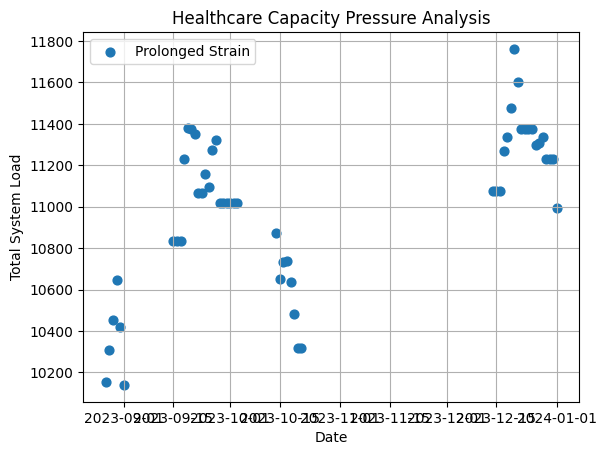

In [50]:
# Highlight prolonged strain periods
plt.scatter(
    df.loc[df["Prolonged Strain"], "Date"],
    df.loc[df["Prolonged Strain"], "Total System Load"],
    marker="o",
    s=40,
    label="Prolonged Strain"
)

plt.title("Healthcare Capacity Pressure Analysis")
plt.xlabel("Date")
plt.ylabel("Total System Load")
plt.legend()
plt.grid(True)

plt.show()

## 6. Export Results

In [52]:
df.to_csv("Healthcare_Pressure_Analysis.csv", index=False)
print("\nPressure analysis completed successfully.")


Pressure analysis completed successfully.
